In [17]:
# from datetime import datetime, timedelta
# import random
# import json

# # Configuration
# user_id = "user"
# start_date = datetime(2025, 2, 1)
# weeks = 12
# days_per_week = 7

# # Routines
# activity_types = {
#     "Running": {
#         "location": "Park_Central",
#         "start_time": "07:00",
#         "duration_minutes": 30
#     },
#     "Trading": {
#         "location": "Home",
#         "start_time": "09:00",
#         "duration_minutes": 30
#     }
# }

# # Drift pattern per week
# activity_schedule = []
# for week in range(1, weeks + 1):
#     if week <= 3:
#         running_count = 7
#         trading_count = 0
#     elif week == 4:
#         running_count = 2
#         trading_count = 2
#     elif week == 5:
#         running_count = 1
#         trading_count = 4
#     else:
#         running_count = 0
#         trading_count = 6
#     activity_schedule.append({
#         "week": week,
#         "Running": running_count,
#         "Trading": trading_count
#     })

# # Simulate KG data
# kg_data = []
# activity_id_counter = 1

# for week_data in activity_schedule:
#     week_start = start_date + timedelta(weeks=week_data["week"] - 1)
#     for activity_type, count in [("Running", week_data["Running"]), ("Trading", week_data["Trading"])]:
#         for _ in range(count):
#             day_offset = random.randint(0, 6)
#             activity_date = week_start + timedelta(days=day_offset)
#             activity_time = datetime.strptime(activity_types[activity_type]["start_time"], "%H:%M")
#             start_dt = activity_date.replace(hour=activity_time.hour, minute=activity_time.minute)
#             end_dt = start_dt + timedelta(minutes=activity_types[activity_type]["duration_minutes"])

#             activity = {
#                 "activity_id": f"activity_{activity_id_counter}",
#                 "type": activity_type,
#                 "user": user_id,
#                 "location": activity_types[activity_type]["location"],
#                 "start_time": start_dt.isoformat(),
#                 "end_time": end_dt.isoformat(),
#                 "week": week_data["week"]
#             }
#             kg_data.append(activity)
#             activity_id_counter += 1

# # Ground truth
# ground_truth = {
#     "drift_periods": [
#         {
#             "type": "RoutineFade",
#             "routine": "MorningRun",
#             "start_week": 4,
#             "end_week": 6
#         },
#         {
#             "type": "RoutineAdoption",
#             "routine": "TradingActivity",
#             "start_week": 4,
#             "solid_by_week": 6
#         }
#     ],
#     "summary": "User transitioned from morning running to regular trading behavior between weeks 4–6, with app usage and search queries indicating financial focus."
# }

# # Save or inspect
# print(json.dumps(ground_truth, indent=2))
# print(json.dumps(kg_data[:3], indent=2))  # Show a few sample entries


In [18]:
# import networkx as nx
# import matplotlib.pyplot as plt

# # Example: load your kg_data from previous simulation here
# # Replace this with your actual kg_data
# # Example format:
# # kg_data = [{"activity_id": "...", "type": "Running", "user": "user", "location": "...", "start_time": "...", "end_time": "...", "week": 1}, ...]

# # Function to filter by week
# def filter_activities_by_week(kg_data, target_week):
#     return [act for act in kg_data if act["week"] == target_week]

# # Node color logic
# def get_node_color(activity_type, week):
#     if activity_type == "Running":
#         return "#003f5c" if week == 1 else "#7a5195" if week == 3 else "#ffffff"
#     elif activity_type == "Trading":
#         return "#80c994" if week == 3 else "#006400" if week == 6 else "#ffffff"
#     return "#d3d3d3"

# # Draw KG for a specific week
# def draw_weekly_kg(kg_data, week, ax):
#     G = nx.DiGraph()
#     week_activities = filter_activities_by_week(kg_data, week)

#     for act in week_activities:
#         user = act["user"]
#         activity = act["activity_id"]
#         location = act["location"]
#         time = act["start_time"][:10]  # Just date
#         act_type = act["type"]

#         # Add nodes
#         G.add_node(user, label="User", color="grey")
#         G.add_node(activity, label=act_type, color=get_node_color(act_type, week))
#         G.add_node(location, label="Location", color="lightgrey")
#         G.add_node(time, label="Date", color="lightgrey")

#         # Add edges
#         G.add_edge(user, activity, label="doesActivity")
#         G.add_edge(activity, location, label="locatedAt")
#         G.add_edge(activity, time, label="occursOn")

#     # Draw graph
#     pos = nx.spring_layout(G, seed=42)
#     node_colors = [data["color"] for _, data in G.nodes(data=True)]
#     # labels = {node: f"{node}\n({data['label']})" for node, data in G.nodes(data=True)]
#     labels = {node: f"{node}\n({data['label']})" for node, data in G.nodes(data=True)}


#     nx.draw(G, pos, ax=ax, node_color=node_colors, with_labels=True, labels=labels,
#             node_size=800, font_size=7, edge_color="gray", arrows=True)
#     ax.set_title(f"Week {week} KG Snapshot")

# # Main plot for weeks 1, 3, and 6
# def visualize_kg_drift(kg_data):
#     fig, axs = plt.subplots(1, 3, figsize=(18, 6))
#     for i, week in enumerate([1, 3, 6]):
#         draw_weekly_kg(kg_data, week, axs[i])
#     plt.tight_layout()
#     plt.show()

# # Run visualization (assuming you have kg_data ready)


In [19]:
# visualize_kg_drift(kg_data)


In [20]:
!pip install rdflib

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/rdflib/term.py", line 2163, in _castLexicalToPython
    return conv_func(lexical)  # type: ignore[arg-type]
           ^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/rdflib/xsd_datetime.py", line 593, in parse_xsd_date
    return parse_date(date_string if not minus else ("-" + date_string))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ValueError: Invalid isoformat string: '2025-W1-D0'
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/rdflib/term.py", line 2163, in _castLexicalToPython
    return conv_func(lexical)  # type: ignore[arg-type]
           ^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/rdflib/xsd_datetime.py", line 593, in parse_xsd_date
    return parse_date(date_string if not minus else ("-" + date_string))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ValueError: I

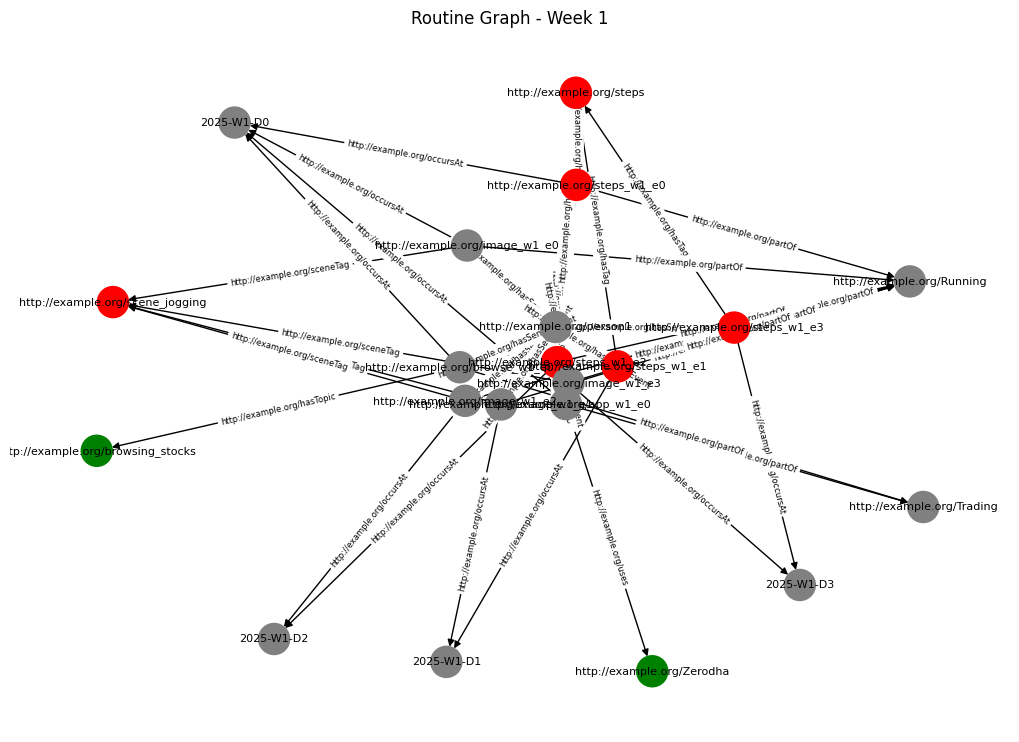

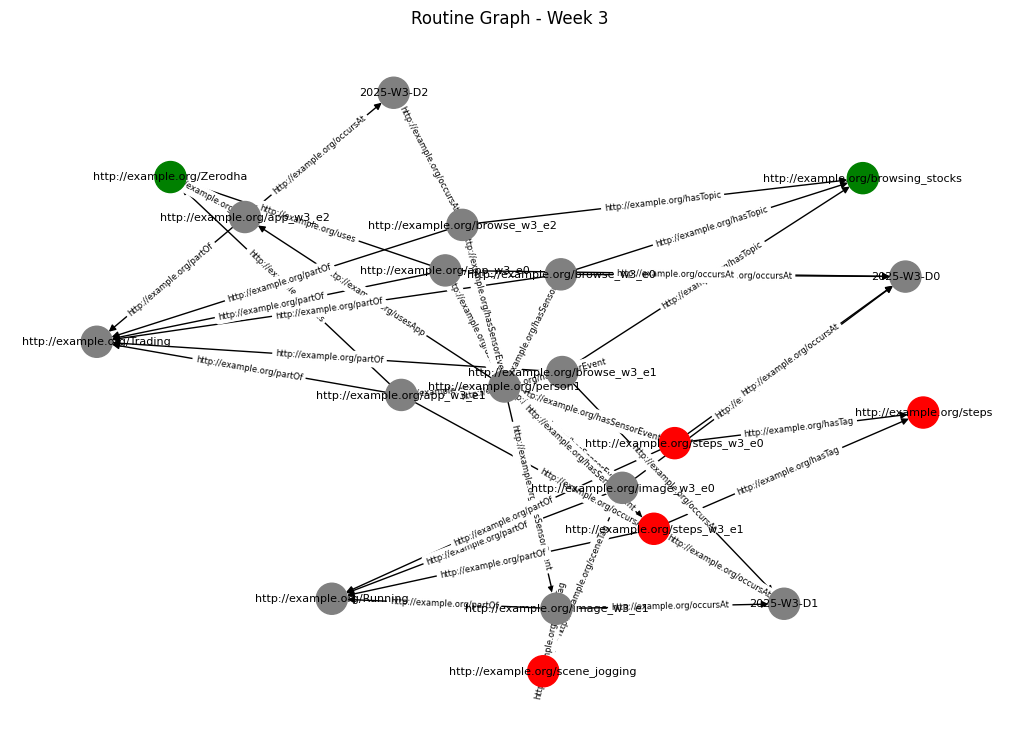

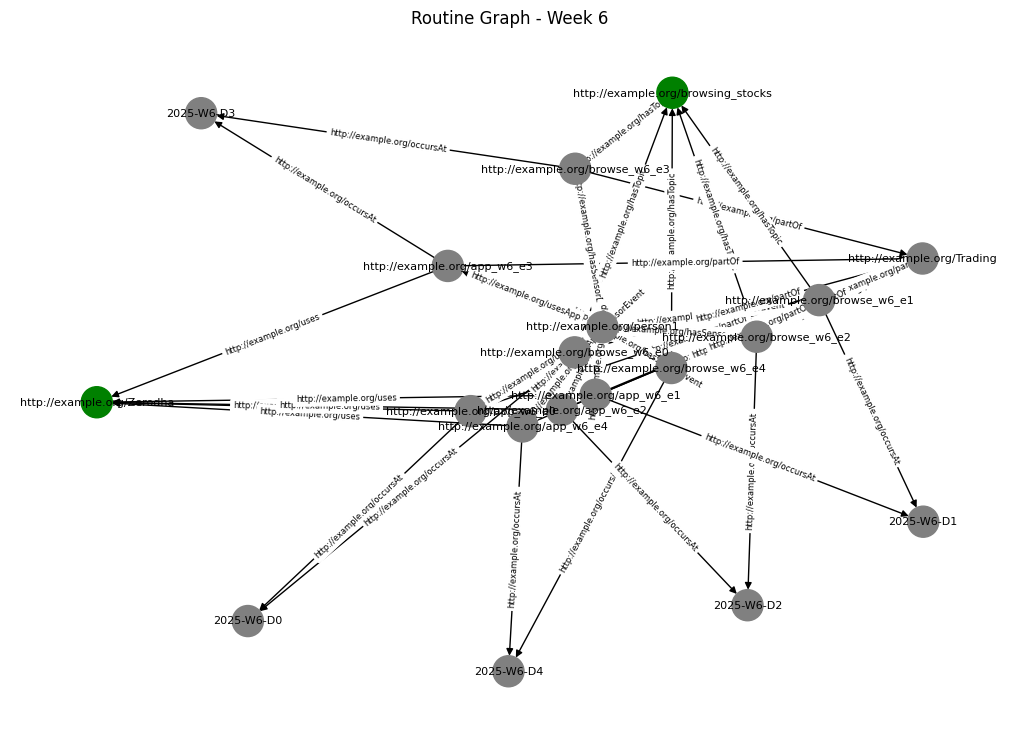

In [10]:
from rdflib import Graph, Namespace, URIRef, Literal
from rdflib.namespace import RDF, XSD
import matplotlib.pyplot as plt
import networkx as nx

# Namespaces
EX = Namespace("http://example.org/")

# Predefined routine entities
running_entities = {
    "steps", "image_jogging", "park", "scene_jogging"
}
trading_entities = {
    "Zerodha", "browsing_stocks", "news_stocks", "finance_app"
}

# Helper: generate triples for a week
def generate_weekly_triples(week, running_count, trading_count):
    g = Graph()
    person = EX.person1

    # Running events
    for i in range(running_count):
        step_event = EX[f"steps_w{week}_e{i}"]
        g.add((person, EX.hasSensorEvent, step_event))
        g.add((step_event, EX.partOf, EX.Running))
        g.add((step_event, EX.occursAt, Literal(f"2025-W{week}-D{i}", datatype=XSD.date)))
        g.add((step_event, EX.hasTag, EX.steps))

        image_event = EX[f"image_w{week}_e{i}"]
        g.add((person, EX.hasSensorEvent, image_event))
        g.add((image_event, EX.partOf, EX.Running))
        g.add((image_event, EX.occursAt, Literal(f"2025-W{week}-D{i}", datatype=XSD.date)))
        g.add((image_event, EX.sceneTag, EX.scene_jogging))

    # Trading events
    for i in range(trading_count):
        app_event = EX[f"app_w{week}_e{i}"]
        g.add((person, EX.usesApp, app_event))
        g.add((app_event, EX.partOf, EX.Trading))
        g.add((app_event, EX.occursAt, Literal(f"2025-W{week}-D{i}", datatype=XSD.date)))
        g.add((app_event, EX.uses, EX.Zerodha))

        browse_event = EX[f"browse_w{week}_e{i}"]
        g.add((person, EX.hasSensorEvent, browse_event))
        g.add((browse_event, EX.partOf, EX.Trading))
        g.add((browse_event, EX.occursAt, Literal(f"2025-W{week}-D{i}", datatype=XSD.date)))
        g.add((browse_event, EX.hasTopic, EX.browsing_stocks))

    return g

# Generate temporal graphs
G_week1 = generate_weekly_triples(1, running_count=4, trading_count=1)
G_week3 = generate_weekly_triples(3, running_count=2, trading_count=3)
G_week6 = generate_weekly_triples(6, running_count=0, trading_count=5)

# Combine for visualization
G_all = {
    "Week 1": G_week1,
    "Week 3": G_week3,
    "Week 6": G_week6
}

def visualize_graph(g, title):
    nxg = nx.DiGraph()
    colors = []

    for s, p, o in g:
        nxg.add_edge(str(s), str(o), label=str(p))
        # Color nodes
        for node in (s, o):
            label = str(node).split("/")[-1]
            if any(ent in label for ent in running_entities):
                nxg.nodes[str(node)]['color'] = 'red'
            elif any(ent in label for ent in trading_entities):
                nxg.nodes[str(node)]['color'] = 'green'
            else:
                nxg.nodes[str(node)]['color'] = 'gray'

    node_colors = [nxg.nodes[n].get('color', 'gray') for n in nxg.nodes()]

    plt.figure(figsize=(10, 7))
    pos = nx.spring_layout(nxg, seed=42)
    nx.draw(nxg, pos, with_labels=True, node_color=node_colors, edge_color='black', font_size=8, node_size=500)
    edge_labels = nx.get_edge_attributes(nxg, 'label')
    nx.draw_networkx_edge_labels(nxg, pos, edge_labels=edge_labels, font_size=6)
    plt.title(title)
    plt.axis('off')
    plt.show()

# Visualize each week
for week, g in G_all.items():
    visualize_graph(g, title=f"Routine Graph - {week}")


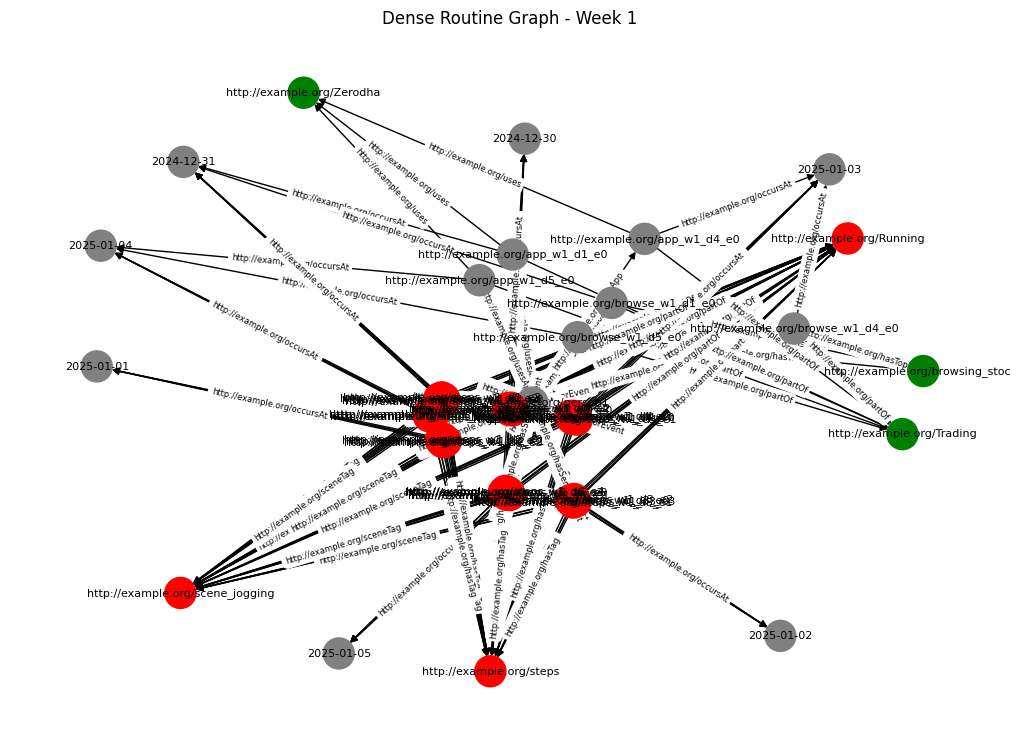

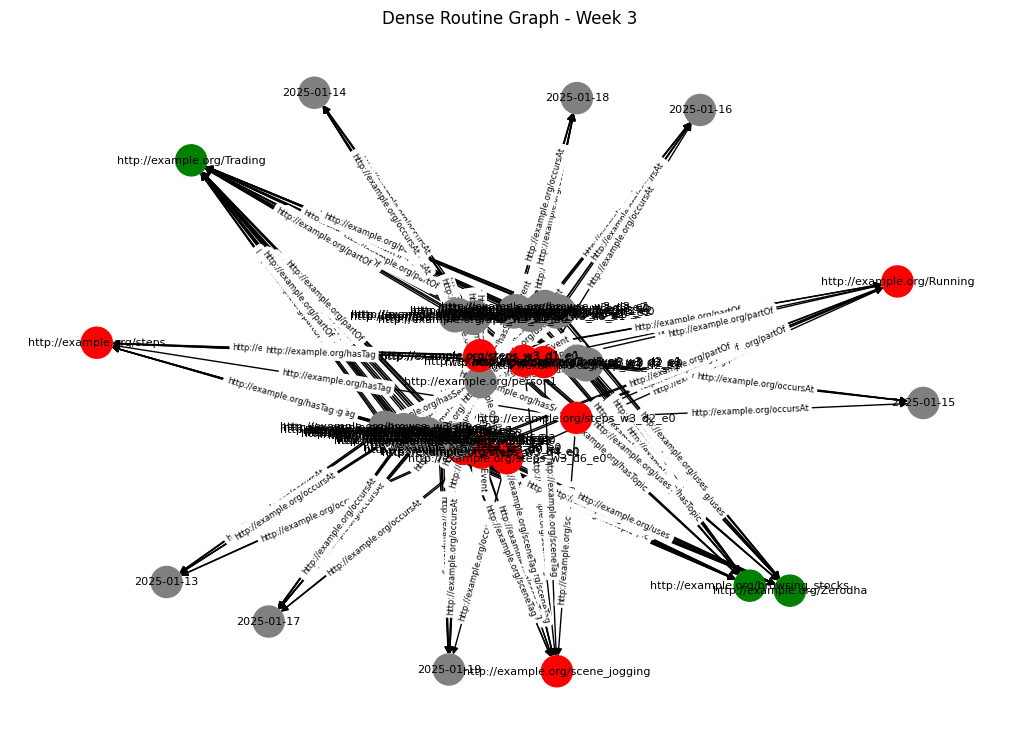

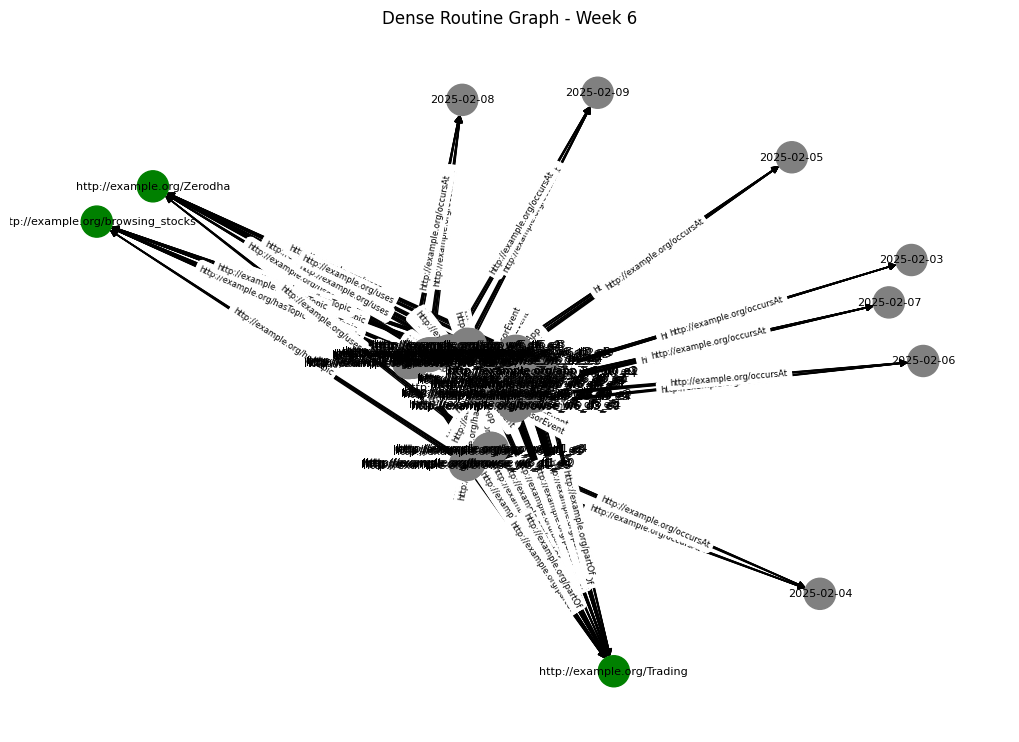

In [15]:
# Let's enhance the graph generation with more granularity and denser data.
# We'll simulate daily data for each week, showing more detailed decay/growth trends.

# def generate_dense_weekly_triples(week, running_pattern, trading_pattern):
#     """
#     running_pattern/trading_pattern: list of 7 integers for each day's event count
#     """
#     g = Graph()
#     person = EX.person1

#     for day in range(7):
#         # Running
#         for i in range(running_pattern[day]):
#             step_event = EX[f"steps_w{week}_d{day}_e{i}"]
#             g.add((person, EX.hasSensorEvent, step_event))
#             g.add((step_event, EX.partOf, EX.Running))
#             g.add((step_event, EX.occursAt, Literal(f"2025-W{week}-D{day}", datatype=XSD.date)))
#             g.add((step_event, EX.hasTag, EX.steps))

#             image_event = EX[f"image_w{week}_d{day}_e{i}"]
#             g.add((person, EX.hasSensorEvent, image_event))
#             g.add((image_event, EX.partOf, EX.Running))
#             g.add((image_event, EX.occursAt, Literal(f"2025-W{week}-D{day}", datatype=XSD.date)))
#             g.add((image_event, EX.sceneTag, EX.scene_jogging))

#         # Trading
#         for i in range(trading_pattern[day]):
#             app_event = EX[f"app_w{week}_d{day}_e{i}"]
#             g.add((person, EX.usesApp, app_event))
#             g.add((app_event, EX.partOf, EX.Trading))
#             g.add((app_event, EX.occursAt, Literal(f"2025-W{week}-D{day}", datatype=XSD.date)))
#             g.add((app_event, EX.uses, EX.Zerodha))

#             browse_event = EX[f"browse_w{week}_d{day}_e{i}"]
#             g.add((person, EX.hasSensorEvent, browse_event))
#             g.add((browse_event, EX.partOf, EX.Trading))
#             g.add((browse_event, EX.occursAt, Literal(f"2025-W{week}-D{day}", datatype=XSD.date)))
#             g.add((browse_event, EX.hasTopic, EX.browsing_stocks))

#     return g

from datetime import date

def get_date_from_weekday(year, week, day_index):
    return date.fromisocalendar(year, week, day_index + 1)

def generate_dense_weekly_triples(week, running_pattern, trading_pattern):
    g = Graph()
    person = EX.person1

    for day in range(7):
        iso_date = get_date_from_weekday(2025, week, day)
        for i in range(running_pattern[day]):
            step_event = EX[f"steps_w{week}_d{day}_e{i}"]
            g.add((person, EX.hasSensorEvent, step_event))
            g.add((step_event, EX.partOf, EX.Running))
            g.add((step_event, EX.occursAt, Literal(iso_date.isoformat(), datatype=XSD.date)))
            g.add((step_event, EX.hasTag, EX.steps))
            g.add((step_event, EX.sceneTag, EX.scene_jogging))

        for i in range(trading_pattern[day]):
            app_event = EX[f"app_w{week}_d{day}_e{i}"]
            g.add((person, EX.usesApp, app_event))
            g.add((app_event, EX.partOf, EX.Trading))
            g.add((app_event, EX.occursAt, Literal(iso_date.isoformat(), datatype=XSD.date)))
            g.add((app_event, EX.uses, EX.Zerodha))

            browse_event = EX[f"browse_w{week}_d{day}_e{i}"]
            g.add((person, EX.hasSensorEvent, browse_event))
            g.add((browse_event, EX.partOf, EX.Trading))
            g.add((browse_event, EX.occursAt, Literal(iso_date.isoformat(), datatype=XSD.date)))
            g.add((browse_event, EX.hasTopic, EX.browsing_stocks))

    return g


# Patterns over the week
# Week 1: High Running, Low Trading
week1_running = [4, 5, 4, 4, 5, 4, 5]
week1_trading = [0, 1, 0, 0, 1, 1, 0]

# Week 3: Mixed
week3_running = [2, 2, 1, 1, 2, 1, 1]
week3_trading = [3, 3, 2, 3, 4, 3, 4]

# Week 6: No Running, High Trading
week6_running = [0, 0, 0, 0, 0, 0, 0]
week6_trading = [5, 6, 6, 5, 6, 7, 6]

# Generate denser graphs
G_dense_week1 = generate_dense_weekly_triples(1, week1_running, week1_trading)
G_dense_week3 = generate_dense_weekly_triples(3, week3_running, week3_trading)
G_dense_week6 = generate_dense_weekly_triples(6, week6_running, week6_trading)

# Visualize them again
G_dense_all = {
    "Week 1": G_dense_week1,
    "Week 3": G_dense_week3,
    "Week 6": G_dense_week6
}

for week, g in G_dense_all.items():
    visualize_graph(g, title=f"Dense Routine Graph - {week}")


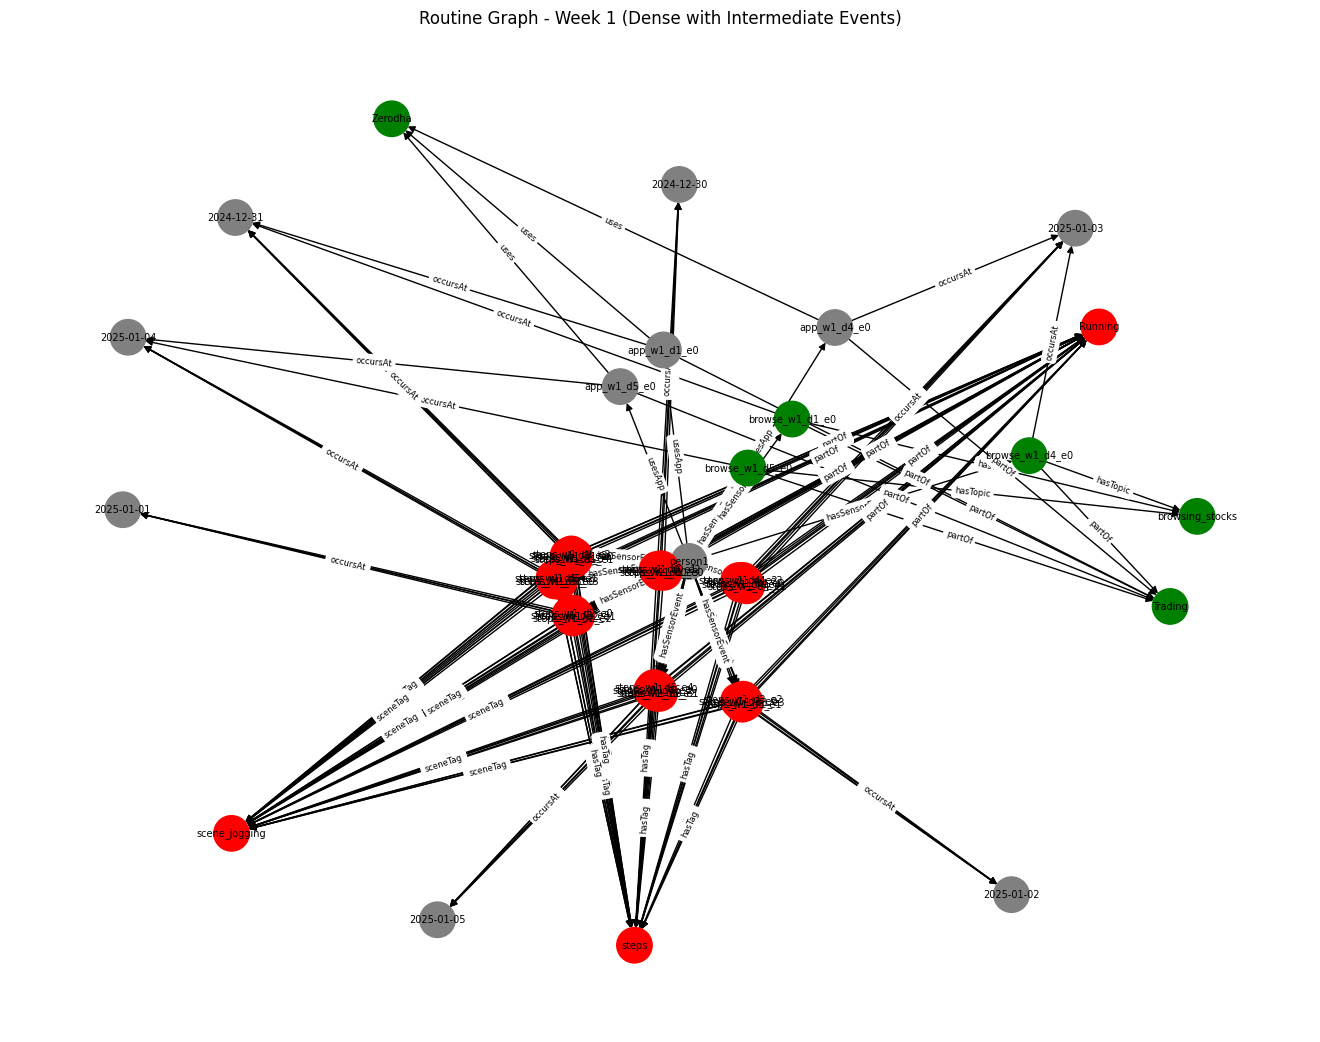

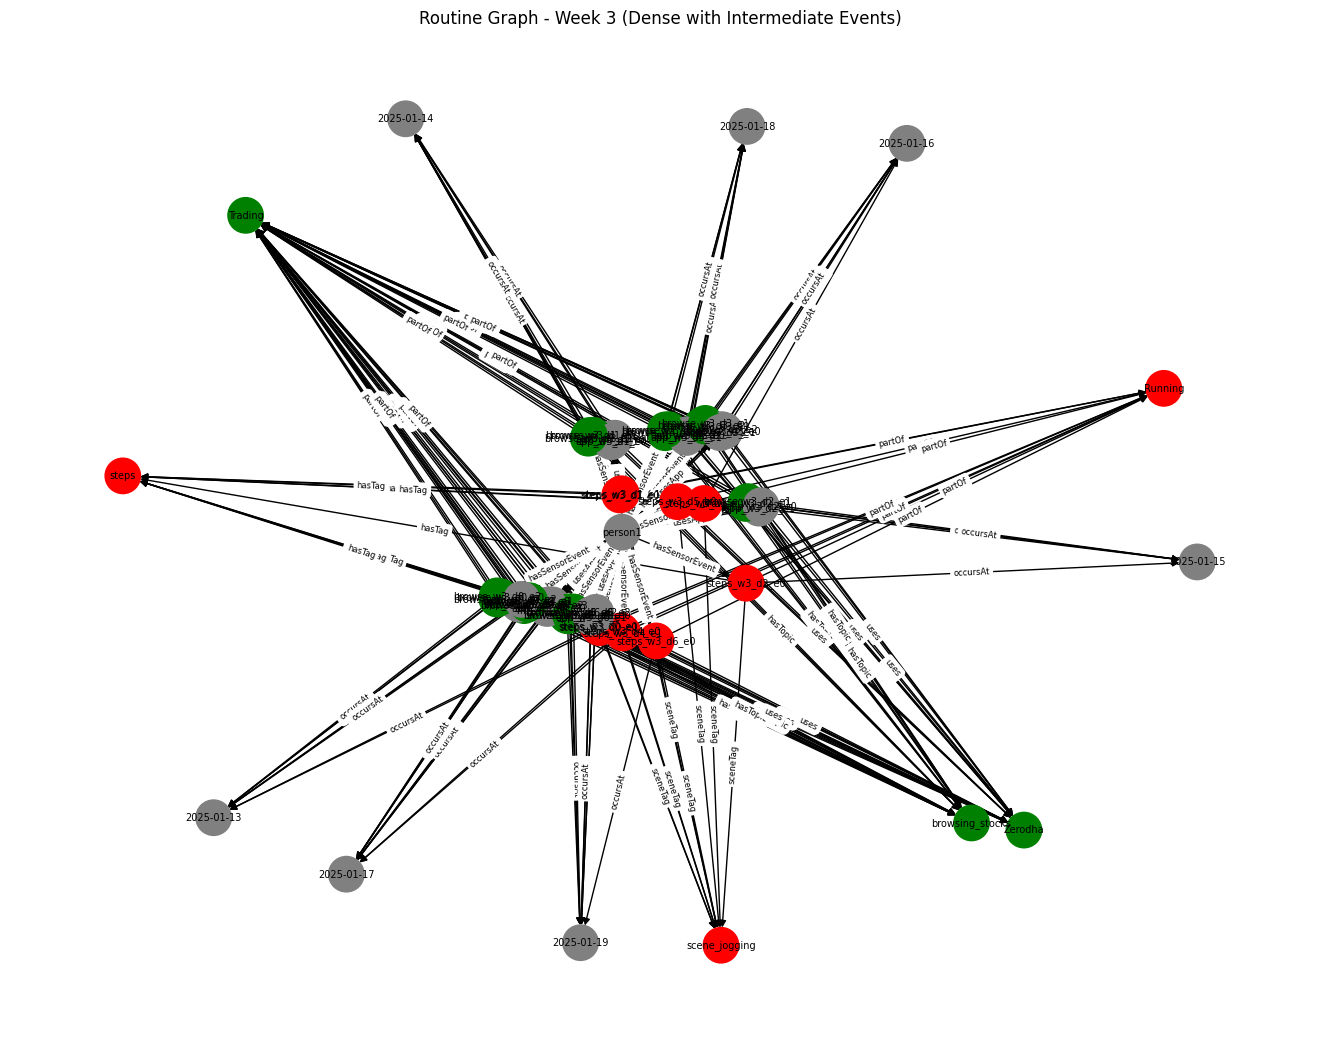

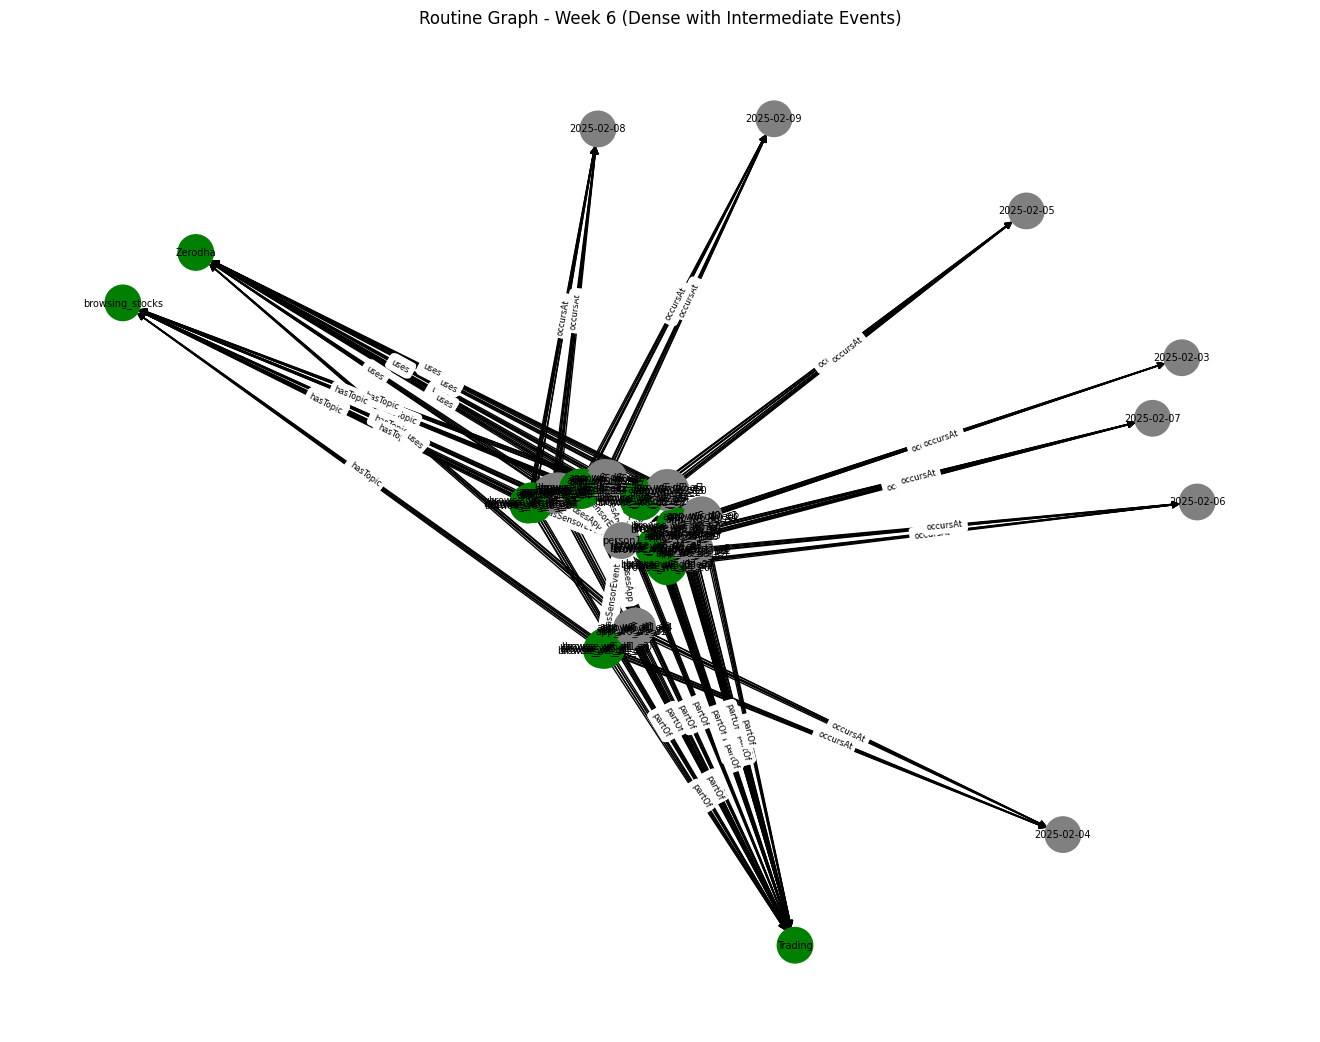

In [16]:
# Define final visualization function for all three weeks
def generate_and_visualize_all_weeks():
    weekly_patterns = {
        "Week 1": ([4, 5, 4, 4, 5, 4, 5], [0, 1, 0, 0, 1, 1, 0]),
        "Week 3": ([2, 2, 1, 1, 2, 1, 1], [3, 3, 2, 3, 4, 3, 4]),
        "Week 6": ([0, 0, 0, 0, 0, 0, 0], [5, 6, 6, 5, 6, 7, 6]),
    }

    def visualize_graph_improved(g, title):
        nxg = nx.DiGraph()
        color_map = {}

        for s, p, o in g:
            s_label = str(s).split("/")[-1]
            o_label = str(o).split("/")[-1]

            for node, label in [(s, s_label), (o, o_label)]:
                node_str = str(node)
                if node_str not in nxg:
                    nxg.add_node(node_str, label=label)
                    if any(ent in label for ent in running_entities) or 'jogging' in label or 'steps' in label:
                        color_map[node_str] = 'red'
                    elif any(ent in label for ent in trading_entities) or 'browse' in label or 'Zerodha' in label:
                        color_map[node_str] = 'green'
                    else:
                        color_map[node_str] = 'gray'

            nxg.add_edge(str(s), str(o), label=str(p).split("/")[-1])

        # Draw graph
        plt.figure(figsize=(13, 10))
        pos = nx.spring_layout(nxg, seed=42)
        node_colors = [color_map.get(n, 'gray') for n in nxg.nodes()]
        nx.draw(nxg, pos, with_labels=True, labels=nx.get_node_attributes(nxg, 'label'),
                node_color=node_colors, edge_color='black', font_size=7, node_size=650)
        edge_labels = nx.get_edge_attributes(nxg, 'label')
        nx.draw_networkx_edge_labels(nxg, pos, edge_labels=edge_labels, font_size=6)
        plt.title(title)
        plt.axis('off')
        plt.show()

    # Generate and visualize each week
    for week_name, (run_pattern, trade_pattern) in weekly_patterns.items():
        week_num = int(week_name.split()[-1])
        g = generate_dense_weekly_triples(week_num, run_pattern, trade_pattern)
        visualize_graph_improved(g, f"Routine Graph - {week_name} (Dense with Intermediate Events)")

generate_and_visualize_all_weeks()


In [13]:
!pip install pyvis

from pyvis.network import Network
from IPython.display import display, HTML

# Utility function: get node color
def get_pyvis_node_color(activity_type, week):
    if activity_type == "Running":
        return "#003f5c" if week == 1 else "#7a5195" if week == 3 else "#ffffff"
    elif activity_type == "Trading":
        return "#80c994" if week == 3 else "#006400" if week == 6 else "#ffffff"
    return "#d3d3d3"

# Function to visualize a week's KG using PyVis
def visualize_week_pyvis(kg_data, week):
    net = Network(height="600px", width="100%", directed=True, notebook=True)
    net.barnes_hut()

    week_activities = filter_activities_by_week(kg_data, week)
    added_nodes = set()

    for act in week_activities:
        user = act["user"]
        activity = act["activity_id"]
        location = act["location"]
        time = act["start_time"][:10]
        act_type = act["type"]

        # Add user node
        if user not in added_nodes:
            net.add_node(user, label=user, color="gray", shape="ellipse")
            added_nodes.add(user)

        # Add activity node
        if activity not in added_nodes:
            net.add_node(activity, label=f"{activity} ({act_type})",
                         color=get_pyvis_node_color(act_type, week), shape="box")
            added_nodes.add(activity)

        # Add location node
        if location not in added_nodes:
            net.add_node(location, label=location, color="lightgray", shape="dot")
            added_nodes.add(location)

        # Add time node
        if time not in added_nodes:
            net.add_node(time, label=time, color="lightgray", shape="dot")
            added_nodes.add(time)

        # Edges
        net.add_edge(user, activity, label="doesActivity")
        net.add_edge(activity, location, label="locatedAt")
        net.add_edge(activity, time, label="occursOn")

    net.set_options('''
    var options = {
      "nodes": {
        "font": {
          "size": 16,
          "face": "Tahoma"
        }
      },
      "edges": {
        "color": {
          "inherit": true
        },
        "smooth": {
          "type": "continuous"
        }
      },
      "physics": {
        "barnesHut": {
          "gravitationalConstant": -20000,
          "springLength": 100
        },
        "minVelocity": 0.75
      }
    }
    ''')

    #net.show(f"week_{week}_kg.html")
    net.save_graph(f"week_{week}_kg.html")
    # return net

# Show graphs for Week 1, 3, and 6
visualize_week_pyvis(kg_data, 1)  # Running Strong
visualize_week_pyvis(kg_data, 3)  # Running Decays, Trading Appears
visualize_week_pyvis(kg_data, 6)  # Running Gone, Trading Strong


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 41.3 MB/s eta 0:00:00


In [14]:
from rdflib import Graph, Namespace, Literal, XSD
from pyvis.network import Network
import random

# Setup
EX = Namespace("http://example.org/")
running_entities = ["Running", "steps", "jogging", "scene_jogging"]
trading_entities = ["Trading", "Zerodha", "browsing_stocks", "finance", "stocks", "charts"]

def generate_dense_weekly_triples(week, running_pattern, trading_pattern):
    g = Graph()
    person = EX.person1

    for day in range(7):
        for i in range(running_pattern[day]):
            step_event = EX[f"steps_w{week}_d{day}_e{i}"]
            g.add((person, EX.hasSensorEvent, step_event))
            g.add((step_event, EX.partOf, EX.Running))
            g.add((step_event, EX.occursAt, Literal(f"2025-W{week}-D{day}", datatype=XSD.date)))
            g.add((step_event, EX.hasTag, EX.steps))
            g.add((step_event, EX.sceneTag, EX.scene_jogging))

        for i in range(trading_pattern[day]):
            app_event = EX[f"app_w{week}_d{day}_e{i}"]
            g.add((person, EX.usesApp, app_event))
            g.add((app_event, EX.partOf, EX.Trading))
            g.add((app_event, EX.occursAt, Literal(f"2025-W{week}-D{day}", datatype=XSD.date)))
            g.add((app_event, EX.uses, EX.Zerodha))

            browse_event = EX[f"browse_w{week}_d{day}_e{i}"]
            g.add((person, EX.hasSensorEvent, browse_event))
            g.add((browse_event, EX.partOf, EX.Trading))
            g.add((browse_event, EX.occursAt, Literal(f"2025-W{week}-D{day}", datatype=XSD.date)))
            g.add((browse_event, EX.hasTopic, EX.browsing_stocks))

    return g

def visualize_pyvis_graph(rdf_graph, filename="graph.html"):
    net = Network(height="800px", width="100%", directed=True, notebook=False)
    net.force_atlas_2based()

    added = set()
    for s, p, o in rdf_graph:
        s_id = str(s)
        o_id = str(o)
        s_label = s_id.split("/")[-1]
        o_label = o_id.split("/")[-1]

        def color_node(label):
            if any(k in label for k in running_entities):
                return "red"
            elif any(k in label for k in trading_entities):
                return "green"
            else:
                return "gray"

        for node_id, label in [(s_id, s_label), (o_id, o_label)]:
            if node_id not in added:
                net.add_node(node_id, label=label, color=color_node(label))
                added.add(node_id)

        for node_id, label in [(s_id, s_label), (o_id, o_label)]:
            if node_id not in added:
                net.add_node(node_id, label=label, color=color_node(label), title=node_id)
                added.add(node_id)


        net.add_edge(s_id, o_id, label=p.split("/")[-1])

    net.show_buttons(filter_=['physics'])
    # net.show(filename)
    net.save_graph(filename)

# Week-wise data
week_patterns = {
    "week1": ([4, 5, 4, 4, 5, 4, 5], [0, 1, 0, 0, 1, 1, 0]),
    "week3": ([2, 2, 1, 1, 2, 1, 1], [3, 3, 2, 3, 4, 3, 4]),
    "week6": ([0, 0, 0, 0, 0, 0, 0], [5, 6, 6, 5, 6, 7, 6]),
}

# Generate and visualize
for week_name, (run, trade) in week_patterns.items():
    g = generate_dense_weekly_triples(int(week_name[-1]), run, trade)
    visualize_pyvis_graph(g, f"{week_name}_routine_graph.html")


Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/rdflib/term.py", line 2163, in _castLexicalToPython
    return conv_func(lexical)  # type: ignore[arg-type]
           ^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/rdflib/xsd_datetime.py", line 593, in parse_xsd_date
    return parse_date(date_string if not minus else ("-" + date_string))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ValueError: Invalid isoformat string: '2025-W1-D0'
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/rdflib/term.py", line 2163, in _castLexicalToPython
    return conv_func(lexical)  # type: ignore[arg-type]
           ^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/rdflib/xsd_datetime.py", line 593, in parse_xsd_date
    return parse_date(date_string if not minus else ("-" + date_string))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ValueError: I